[Previous: Module 6: Graphs](06_Graphs.ipynb)  |  [Course Index](00_Start_Here.ipynb)

# Module 7: Dynamic Programming

**Learning objectives.** After this module you can:

* recognise overlapping subproblems and see, in a plot, how much work naive recursion repeats;
* write the same solution top-down (memoisation) and bottom-up (tabulation);
* solve coin change, edit distance and 0/1 knapsack by building and reading a table;
* apply a four-question checklist to decide whether a new problem is a dynamic programming problem.

**Prerequisites.** [Module 4](04_Recursion_Searching_and_Sorting.ipynb) (recursion).

## 1. The problem with naive recursion

Module 4's `fib(25)` made about 250,000 calls to produce a number you can write on one hand. The reason is **overlapping subproblems**:
`fib(23)` is computed twice, `fib(22)` three times, `fib(10)` thousands of times. The calls form a tree that doubles at every level.

**Dynamic programming** (DP) is one idea: solve each subproblem **once** and remember the answer. The plot below counts calls for the naive version and for a
version with a memo. One curve is exponential, the other is a straight line.

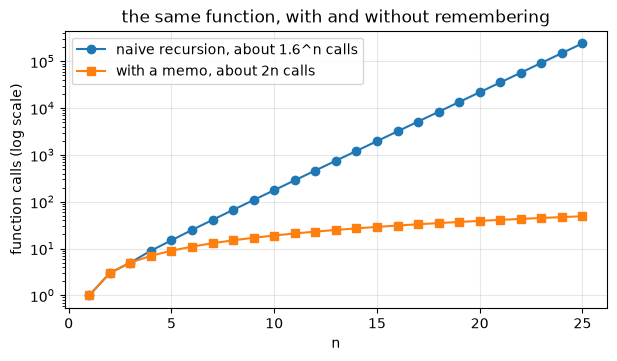

fib(25): naive 242,785 calls, memo 49 calls


In [1]:
import random
import matplotlib.pyplot as plt
from functools import lru_cache
from dsalab import draw_table, time_it

def fib_naive(n, counter):
    counter[0] += 1
    return n if n < 2 else fib_naive(n - 1, counter) + fib_naive(n - 2, counter)

def fib_memo(n, memo, counter):
    counter[0] += 1
    if n in memo:
        return memo[n]
    memo[n] = n if n < 2 else fib_memo(n - 1, memo, counter) + fib_memo(n - 2, memo, counter)
    return memo[n]

ns = list(range(1, 26))
naive_calls, memo_calls = [], []
for n in ns:
    c = [0]; fib_naive(n, c); naive_calls.append(c[0])
    c = [0]; fib_memo(n, {}, c); memo_calls.append(c[0])

plt.figure(figsize=(7, 3.6))
plt.plot(ns, naive_calls, "o-", label="naive recursion, about 1.6^n calls")
plt.plot(ns, memo_calls, "s-", label="with a memo, about 2n calls")
plt.yscale("log"); plt.xlabel("n"); plt.ylabel("function calls (log scale)"); plt.legend(); plt.grid(alpha=0.3)
plt.title("the same function, with and without remembering"); plt.show()
print(f"fib(25): naive {naive_calls[-1]:,} calls, memo {memo_calls[-1]} calls")

## 2. Two ways to write it: top-down and bottom-up

* **Memoisation (top-down)** keeps the recursive shape and adds a cache. Python's `functools.lru_cache` does it in one line.
* **Tabulation (bottom-up)** fills a table from the smallest subproblem up, no recursion at all. Same answers, same complexity, and often less memory
  because you can keep only the last few rows.

Both appear below for Fibonacci and for its twin, "how many ways can you climb n stairs taking 1 or 2 steps at a time?", which is the same recurrence with different base cases.

In [2]:
@lru_cache(maxsize=None)
def fib_top_down(n):
    return n if n < 2 else fib_top_down(n - 1) + fib_top_down(n - 2)

def fib_bottom_up(n):
    a, b = 0, 1                           # only the last two values are needed: O(1) memory
    for _ in range(n):
        a, b = b, a + b
    return a

def stairs(n):
    ways = [1, 1] + [0] * (n - 1)         # ways[0] = 1 (stand still), ways[1] = 1
    for i in range(2, n + 1):
        ways[i] = ways[i - 1] + ways[i - 2]
    return ways[n]

print("fib(90) top-down:  ", fib_top_down(90))
print("fib(90) bottom-up: ", fib_bottom_up(90))
print("ways to climb 10 stairs:", stairs(10))
print("time for fib_bottom_up(10000):", f"{time_it(fib_bottom_up, 10000) * 1000:.2f} ms")

fib(90) top-down:   2880067194370816120
fib(90) bottom-up:  2880067194370816120
ways to climb 10 stairs: 89
time for fib_bottom_up(10000): 0.94 ms


## 3. Coin change: where greedy goes wrong

Make an amount with the fewest coins. Greedy (always take the largest coin that fits) works for real currencies, and fails for others:
with coins {1, 4, 6} and amount 8, greedy takes 6 + 1 + 1 while the best is 4 + 4.

The DP table `dp[a]` = fewest coins for amount a, built from `dp[0] = 0` upward: for each amount, try every coin as the last one and take the best.
Storing which coin won lets you rebuild the actual coins.

In [3]:
def min_coins(coins, amount):
    INF = float("inf")
    dp, choice = [0] + [INF] * amount, [None] * (amount + 1)
    for a in range(1, amount + 1):
        for c in coins:
            if c <= a and dp[a - c] + 1 < dp[a]:
                dp[a], choice[a] = dp[a - c] + 1, c
    used, a = [], amount
    while a > 0:
        used.append(choice[a]); a -= choice[a]
    return dp[amount], used

def greedy_coins(coins, amount):
    used = []
    for c in sorted(coins, reverse=True):
        while amount >= c:
            used.append(c); amount -= c
    return used

for coins, amount in [((1, 4, 6), 8), ((1, 5, 10, 25), 63), ((1, 3, 4), 6)]:
    best, used = min_coins(coins, amount)
    g = greedy_coins(coins, amount)
    print(f"coins {coins}, amount {amount}: DP {best} coins {used}   greedy {len(g)} coins {g}" + ("   <- greedy loses" if len(g) > best else ""))

coins (1, 4, 6), amount 8: DP 2 coins [4, 4]   greedy 3 coins [6, 1, 1]   <- greedy loses
coins (1, 5, 10, 25), amount 63: DP 6 coins [1, 1, 1, 10, 25, 25]   greedy 6 coins [25, 25, 10, 1, 1, 1]
coins (1, 3, 4), amount 6: DP 2 coins [3, 3]   greedy 3 coins [4, 1, 1]   <- greedy loses


### Lab: Coin Change Lab

Drag the amount and watch the table fill. Type a different coin set. Find an amount where greedy needs two more coins than the optimum.

Coin Change Lab (static preview). Run this cell in JupyterLab for the interactive version.


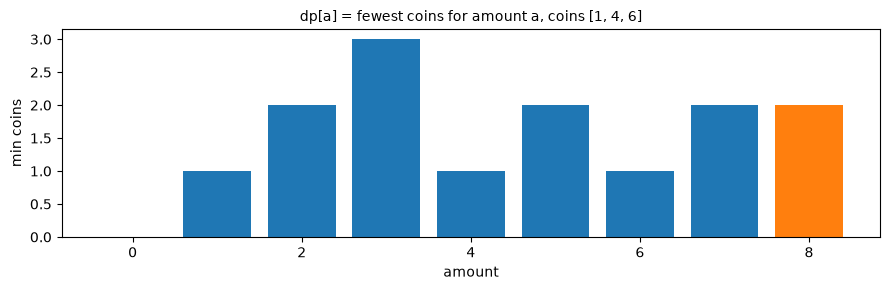

In [4]:
from dsalab import coin_change_lab

coin_change_lab()

## 4. Edit distance: a two-dimensional table

How many single-character edits (insert, delete, replace) turn one word into another? Spell checkers and DNA alignment run on this.
The table `d[i][j]` is the distance between the first i letters of A and the first j letters of B:

$$d[i][j] = \min\big(d[i-1][j] + 1,\; d[i][j-1] + 1,\; d[i-1][j-1] + [A_i \ne B_j]\big)$$

Row 0 and column 0 are the trivial cases (turning a prefix into nothing, or nothing into a prefix). The answer is the bottom-right cell, and walking back
along the minimum choices recovers the edits themselves.

edit distance kitten -> sitting = 3


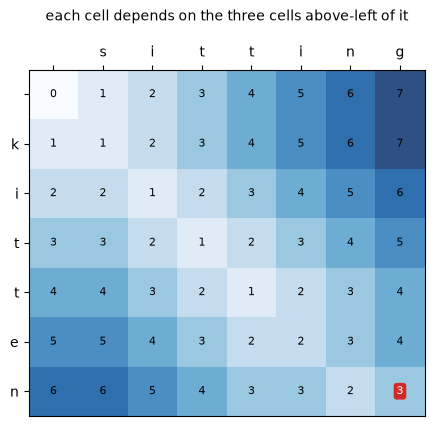

In [5]:
def edit_distance(a, b):
    d = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a) + 1): d[i][0] = i
    for j in range(len(b) + 1): d[0][j] = j
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            same = a[i - 1] == b[j - 1]
            d[i][j] = min(d[i - 1][j] + 1, d[i][j - 1] + 1, d[i - 1][j - 1] + (0 if same else 1))
    return d

a, b = "kitten", "sitting"
d = edit_distance(a, b)
print(f"edit distance {a} -> {b} = {d[-1][-1]}")
draw_table(d, [""] + list(a), [""] + list(b), title="each cell depends on the three cells above-left of it", highlight={(len(a), len(b))})

### Lab: Edit Distance Lab

Type any two words. The red path is the answer read backwards; the operations under the table are the actual edits.

Edit Distance Lab (static preview). Run this cell in JupyterLab for the interactive version.


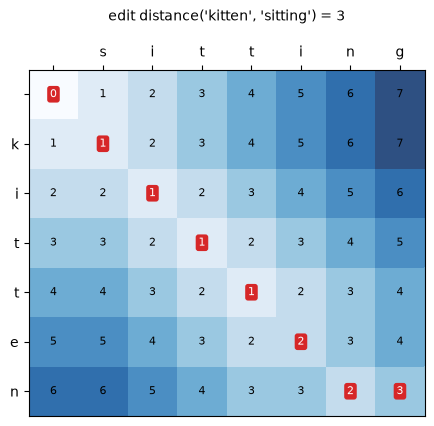

In [6]:
from dsalab import edit_distance_lab

edit_distance_lab()

## 5. 0/1 knapsack: choose or skip

Items have a weight and a value; the bag holds weight W. Each item is taken whole or not at all. Trying every subset is $O(2^n)$.
The DP table `best[i][w]` = best value using the first i items within weight w, and each cell asks one question: **skip item i, or take it** (if it fits)?

$$best[i][w] = \max\big(best[i-1][w],\; best[i-1][w - w_i] + v_i\big)$$

That is $O(nW)$ cells, each O(1). The pattern "skip or take" recurs in dozens of problems.

best value within weight 8: 140, take ['stove', 'book', 'food']


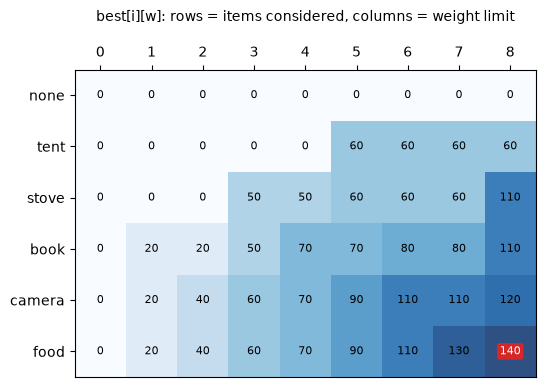

In [7]:
items = [("tent", 5, 60), ("stove", 3, 50), ("book", 1, 20), ("camera", 2, 40), ("food", 4, 70)]   # name, weight, value
W = 8

def knapsack(items, W):
    n = len(items)
    best = [[0] * (W + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        name, wt, val = items[i - 1]
        for w in range(W + 1):
            best[i][w] = best[i - 1][w]                                  # skip
            if wt <= w:
                best[i][w] = max(best[i][w], best[i - 1][w - wt] + val)   # take
    chosen, w = [], W                                                     # walk back to find the items
    for i in range(n, 0, -1):
        if best[i][w] != best[i - 1][w]:
            chosen.append(items[i - 1][0]); w -= items[i - 1][1]
    return best, chosen[::-1]

best, chosen = knapsack(items, W)
print(f"best value within weight {W}: {best[-1][-1]}, take {chosen}")
draw_table(best, ["none"] + [it[0] for it in items], list(range(W + 1)), title="best[i][w]: rows = items considered, columns = weight limit", highlight={(len(items), W)})

## 6. How to spot a DP problem

Ask four questions:

1. **Can the answer be built from answers to smaller versions of the same question?** (Optimal substructure.) Fewest coins for 8 uses fewest coins for 8 minus a coin.
2. **Do those smaller versions repeat?** (Overlapping subproblems.) If not, plain recursion or divide and conquer is enough.
3. **What are the parameters that identify a subproblem?** They are the table's dimensions: amount; (i, j) prefix lengths; (item, weight).
4. **What is the recurrence, and what are the base cases?** Write it as a formula first, then as a loop over the table in an order that has the needed cells ready.

If you can answer all four, the code almost writes itself: allocate the table, fill the base cases, loop, read the answer, optionally walk back for the choices.

## Try it yourself

**Exercise 1.** Longest common subsequence of two strings, with the table drawn. (`lcs("ABCBDAB", "BDCABA")` has length 4.)

**Exercise 2.** House robber: houses in a row hold money, you cannot rob two adjacent ones. Maximum you can take? Recurrence: `best[i] = max(best[i-1], best[i-2] + money[i])`.

**Exercise 3.** Number of paths from the top-left to the bottom-right of an r x c grid moving only right or down. Then add blocked cells.

**Exercise 4 (challenge).** Longest increasing subsequence in $O(n^2)$, then read about the $O(n \log n)$ version using `bisect`.

<details><summary>Solutions</summary>

```python
# Exercise 1
def lcs(a, b):
    L = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            L[i][j] = L[i - 1][j - 1] + 1 if a[i - 1] == b[j - 1] else max(L[i - 1][j], L[i][j - 1])
    return L[-1][-1], L
n, L = lcs("ABCBDAB", "BDCABA"); print(n)
draw_table(L, [""] + list("ABCBDAB"), [""] + list("BDCABA"))

# Exercise 2
def rob(money):
    prev2, prev1 = 0, 0
    for m in money:
        prev2, prev1 = prev1, max(prev1, prev2 + m)
    return prev1
print(rob([2, 7, 9, 3, 1]))          # 12

# Exercise 3
def grid_paths(r, c, blocked=()):
    ways = [[0] * c for _ in range(r)]
    for i in range(r):
        for j in range(c):
            if (i, j) in blocked: continue
            if i == 0 and j == 0: ways[i][j] = 1
            else: ways[i][j] = (ways[i - 1][j] if i else 0) + (ways[i][j - 1] if j else 0)
    return ways[-1][-1]
print(grid_paths(3, 7), grid_paths(3, 3, blocked={(1, 1)}))    # 28, 2

# Exercise 4
def lis(a):
    best = [1] * len(a)
    for i in range(len(a)):
        for j in range(i):
            if a[j] < a[i]: best[i] = max(best[i], best[j] + 1)
    return max(best)
print(lis([10, 9, 2, 5, 3, 7, 101, 18]))   # 4
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [8]:
from dsalab import quiz

quiz(7)

Checkpoint quiz, Module 7 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Dynamic programming pays off when a problem has
    a) random inputs
    b) overlapping subproblems and optimal substructure
    c) no base case
    d) only one solution

Q2. Memoization is
    a) bottom-up table filling
    b) top-down recursion with a cache of results
    c) a sorting technique
    d) a kind of greedy choice

Q3. Naive recursive Fibonacci has running time about
    a) O(n)
    b) O(n log n)
    c) O(2^n)
    d) O(n^2)

Q4. For coins {1, 4, 6} and amount 8, the greedy approach gives
    a) 2 coins, the optimum
    b) 3 coins, worse than the optimum of 2
    c) 4 coins
    d) no answer


## Key takeaways

* Overlapping subproblems make naive recursion exponential; remembering answers makes it polynomial.
* Memoisation adds a cache to recursion; tabulation fills a table bottom-up. Same complexity, pick the clearer one.
* Coin change, edit distance and knapsack are the three template problems: one-dimensional, two-dimensional over prefixes, and "skip or take".
* Four questions decide whether DP applies: substructure, overlap, subproblem parameters, recurrence with base cases.

## Where to go next

* Practice on a problem site, one topic at a time, using the labs here to visualise what you build.
* Read about balanced trees (AVL, red-black), union-find, tries and segment trees: the next tier of structures.
* *Grokking Algorithms* (Bhargava) is the friendliest book; *Introduction to Algorithms* (Cormen et al.) is the reference.

You have reached the end of the course. Go back to the [Course Index](00_Start_Here.ipynb), or rebuild any algorithm here from memory: that is the real test.

[Previous: Module 6: Graphs](06_Graphs.ipynb)  |  [Course Index](00_Start_Here.ipynb)